# Generative Adversarial Network for MNIST

This notebook is self-contained for Colab or local Jupyter use. It includes the helper utilities directly in the notebook, loads the MNIST dataset, trains a Generative Adversarial Network (GAN) to generate handwritten digits, and evaluates the image generation quality at different training stages.

Source overview:
- Helper cell: adapted from `helper.py` to ensure the notebook remains completely self-contained.
- Data loading and preprocessing cell: adapted from `5_GAN Generation of MNIST digits/GAN_template.py`.
- Model, training, and evaluation cells: adapted from `5_GAN Generation of MNIST digits/GAN_template.py` and extended for standalone notebook use.

If you run this in Colab, all modules will load and run automatically since it uses built-in torchvision for dataset downloading.

In [1]:
# Source: adapted from helper.py and included directly to make the notebook self-contained.
import copy
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils


def normalize(labels, p):
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges


def denormalize(labels, ranges):
    return labels * (ranges[1] - ranges[0]) + ranges[0]


def denormalize_std(uncertainty, ranges):
    return uncertainty * (ranges[1] - ranges[0])


def get_normalized_data(data_path, return_SNR=False):
    spectra = np.load(f"{data_path}/spectra.npy")
    spectra_length = spectra.shape[1]

    labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h"]
    labels = np.load(f"{data_path}/labels.npy")
    SNR = labels[:, -1]
    labels = labels[:, :-1]

    labelNames = labelNames[-3:]
    labels = labels[:, -3:]
    n_labels = labels.shape[1]

    labels, ranges = normalize(labels, 0.05)
    spectra = np.log(np.maximum(spectra, 0.2))

    if return_SNR:
        return spectra, labels, spectra_length, n_labels, labelNames, ranges, SNR
    return spectra, labels, spectra_length, n_labels, labelNames, ranges


def train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience,
                device, plot_fn=None, plot_interval=10, plot_kwargs=None, model_name=None):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(num_epochs):
        start_time = time.time()

        model.train()
        total_train_loss = 0.0
        for step, (batch_spectra, batch_labels) in enumerate(train_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
            optimizer.zero_grad()
            loss = loss_function(batch_spectra, batch_labels, model)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if (step + 1) % 10 == 0:
                sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
                sys.stdout.flush()

        sys.stdout.write("\n")

        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
                val_loss = loss_function(batch_spectra, batch_labels, model)
                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        epoch_time = time.time() - start_time
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if epoch % plot_interval == 0:
            if plot_fn is not None:
                assert plot_kwargs is not None
                assert "test_loader" in plot_kwargs.keys()
                assert "ranges" in plot_kwargs.keys()
                assert "plot_folder" in plot_kwargs.keys()
                plot_fn(model,
                        plot_kwargs["test_loader"],
                        loss_function,
                        device,
                        plot_kwargs["ranges"],
                        train_losses,
                        val_losses,
                        plot_folder=plot_kwargs["plot_folder"],
                        suffix="epoch_%.5d" % epoch)

    return train_losses, val_losses, best_model


def evaluate_model(model, test_loader, loss_function, device):
    print("Evaluating model on the test dataset...")
    model.eval()
    total_test_loss = 0.0
    all_predictions = []
    all_true_labels = []
    first_batch_spectra = None
    first_batch_labels = None

    with torch.no_grad():
        for batch_index, (batch_spectra, batch_labels) in enumerate(test_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
            predictions = model(batch_spectra)
            test_loss = loss_function(batch_spectra, batch_labels, model)
            total_test_loss += test_loss.item()
            all_predictions.append(predictions.cpu())
            all_true_labels.append(batch_labels.cpu())

            if batch_index == 0:
                first_batch_spectra = batch_spectra
                first_batch_labels = batch_labels

    avg_test_loss = total_test_loss / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")
    return torch.cat(all_predictions).numpy(), torch.cat(all_true_labels).numpy(), first_batch_spectra, first_batch_labels


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


Training samples: 60000


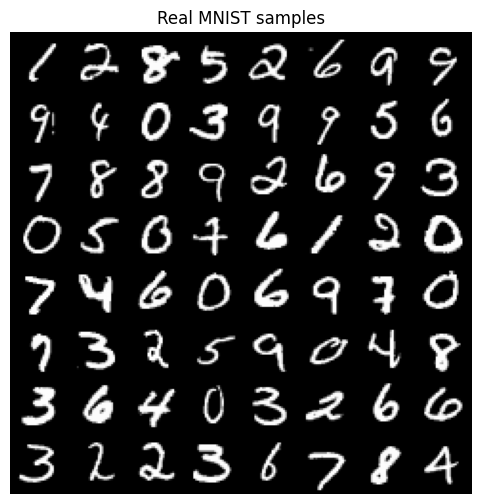

In [2]:
# Source: adapted from 5_GAN Generation of MNIST digits/GAN_template.py to download and load the MNIST dataset.
learning_rate = 2e-4
batch_size = 128
num_epochs = 30
latent_dim = 128
image_dim = 28 * 28
sample_interval = 5

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# For Colab, dataset downloading directly into the local folder:
dataset_root = './dataset'
mnist = datasets.MNIST(root=dataset_root, train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=batch_size, shuffle=True, drop_last=True)

print('Training samples:', len(mnist))
real_batch, _ = next(iter(loader))
grid = utils.make_grid(real_batch[:64], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis('off')
plt.title('Real MNIST samples')
plt.show()

In [3]:
# Source: adapted from 5_GAN Generation of MNIST digits/GAN_template.py to define the Generator and Discriminator models.
def weights_init(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, 0.0, 0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class Generator(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, image_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.network(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(image_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x)


generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()
opt_generator = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
opt_discriminator = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

print(generator)
print(discriminator)

Generator(
  (network): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)
Discriminator(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, i

In [4]:
def train_gan(generator, discriminator, loader, num_epochs, latent_dim, device, sample_interval=5):
    fixed_noise = torch.randn(64, latent_dim, device=device)
    sample_history = []
    g_losses = []
    d_losses = []

    def take_snapshot(epoch_label):
        with torch.no_grad():
            fake = generator(fixed_noise).view(-1, 1, 28, 28).detach().cpu()
        sample_history.append((epoch_label, fake))

    take_snapshot(0)

    for epoch in range(1, num_epochs + 1):
        generator.train()
        discriminator.train()
        total_g_loss = 0.0
        total_d_loss = 0.0

        for batch_idx, (real_images, _) in enumerate(loader):
            real_images = real_images.view(real_images.size(0), -1).to(device)
            batch_size = real_images.size(0)
            valid = torch.ones((batch_size, 1), device=device)
            fake = torch.zeros((batch_size, 1), device=device)

            opt_discriminator.zero_grad()
            real_loss = criterion(discriminator(real_images), valid)
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise)
            fake_loss = criterion(discriminator(fake_images.detach()), fake)
            d_loss = 0.5 * (real_loss + fake_loss)
            d_loss.backward()
            opt_discriminator.step()

            opt_generator.zero_grad()
            noise = torch.randn(batch_size, latent_dim, device=device)
            generated_images = generator(noise)
            g_loss = criterion(discriminator(generated_images), valid)
            g_loss.backward()
            opt_generator.step()

            total_d_loss += d_loss.item()
            total_g_loss += g_loss.item()

            if batch_idx % 200 == 0:
                print(f'\rEpoch {epoch:03d}/{num_epochs} | Batch {batch_idx:04d}/{len(loader)} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}', end='')

        avg_d_loss = total_d_loss / len(loader)
        avg_g_loss = total_g_loss / len(loader)
        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)
        print(f'\nEpoch {epoch:03d} summary | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}')

        if epoch % sample_interval == 0 or epoch == num_epochs:
            take_snapshot(epoch)

    return g_losses, d_losses, sample_history


g_losses, d_losses, sample_history = train_gan(
    generator,
    discriminator,
    loader,
    num_epochs=num_epochs,
    latent_dim=latent_dim,
    device=device,
    sample_interval=sample_interval,
)

Epoch 001/30 | Batch 0400/468 | D loss: 0.5617 | G loss: 1.6993
Epoch 001 summary | D loss: 0.5973 | G loss: 1.0817
Epoch 002/30 | Batch 0400/468 | D loss: 0.5128 | G loss: 1.4117
Epoch 002 summary | D loss: 0.5482 | G loss: 1.3801
Epoch 003/30 | Batch 0400/468 | D loss: 0.4854 | G loss: 0.5911
Epoch 003 summary | D loss: 0.5513 | G loss: 1.2801
Epoch 004/30 | Batch 0400/468 | D loss: 0.5999 | G loss: 1.1095
Epoch 004 summary | D loss: 0.5672 | G loss: 1.1785
Epoch 005/30 | Batch 0400/468 | D loss: 0.5707 | G loss: 1.7002
Epoch 005 summary | D loss: 0.5861 | G loss: 1.0979
Epoch 006/30 | Batch 0400/468 | D loss: 0.6629 | G loss: 0.9390
Epoch 006 summary | D loss: 0.6008 | G loss: 1.0174
Epoch 007/30 | Batch 0400/468 | D loss: 0.6307 | G loss: 1.1018
Epoch 007 summary | D loss: 0.6119 | G loss: 0.9773
Epoch 008/30 | Batch 0400/468 | D loss: 0.6396 | G loss: 0.7946
Epoch 008 summary | D loss: 0.6235 | G loss: 0.9552
Epoch 009/30 | Batch 0400/468 | D loss: 0.6735 | G loss: 0.8933
Epoch 00

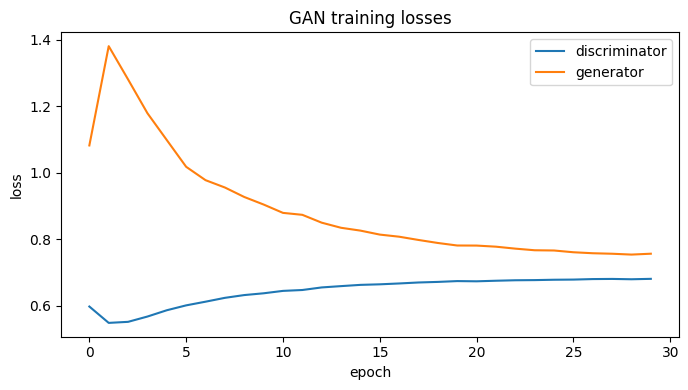

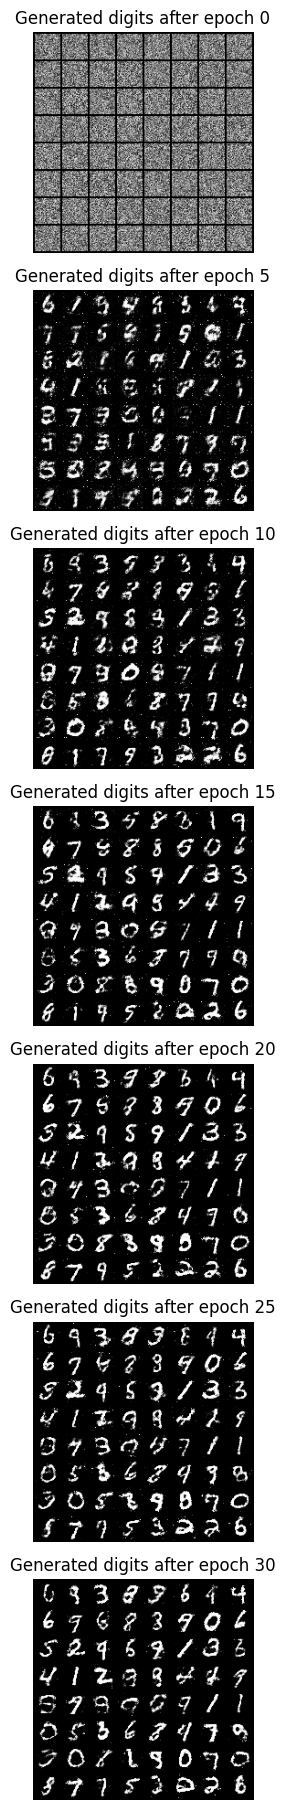

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(d_losses, label='discriminator')
plt.plot(g_losses, label='generator')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('GAN training losses')
plt.legend()
plt.tight_layout()
plt.show()

rows = len(sample_history)
fig, axes = plt.subplots(rows, 1, figsize=(8, 2.6 * rows))
if rows == 1:
    axes = [axes]

for axis, (epoch_label, fake_batch) in zip(axes, sample_history):
    grid = utils.make_grid(fake_batch[:64], nrow=8, normalize=True, value_range=(-1, 1))
    axis.imshow(grid.permute(1, 2, 0))
    axis.set_title(f'Generated digits after epoch {epoch_label}')
    axis.axis('off')

plt.tight_layout()
plt.show()